# 1. Importing Libraries

In [19]:
# ============================================================================
# 1. IMPORTS AND SETUP
# ============================================================================
import pandas as pd
import numpy as np
import warnings
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ML and modeling
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# Suppress warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# 2. Loading the Dataset

In [20]:
# ============================================================================
# 2. DATA LOADING AND INITIAL INSPECTION
# ============================================================================
print("=" * 80)
print("LOADING DATASET")
print("=" * 80)

# Load dataset
data = pd.read_csv('/kaggle/input/agrisense-dataset/full_price_data.csv')
print(f"Dataset shape: {data.shape}")
print(f"\nColumns: {data.columns.tolist()}")
print(f"\nData types:\n{data.dtypes}")
print(f"\nMissing values:\n{data.isnull().sum()}")

# Display sample
print("\nFirst 5 rows:")
print(data.head())

LOADING DATASET
Dataset shape: (123984, 20)

Columns: ['report_date', 'category', 'item_raw', 'item_standard', 'origin_type', 'price_type', 'market', 'unit_raw', 'unit_std', 'currency', 'prev_window_label', 'price_prev', 'today_label', 'price_today', 'special_notes', 'source_doc_id', 'source_doc_date', 'source_url', 'ingested_at', 'row_id']

Data types:
report_date           object
category              object
item_raw              object
item_standard         object
origin_type           object
price_type            object
market                object
unit_raw              object
unit_std              object
currency              object
prev_window_label     object
price_prev           float64
today_label           object
price_today          float64
special_notes         object
source_doc_id         object
source_doc_date       object
source_url            object
ingested_at           object
row_id                object
dtype: object

Missing values:
report_date               0
categ

# 3. Data cleaning and preprocessing

In [21]:
# ============================================================================
# 3. DATA CLEANING AND PREPROCESSING
# ============================================================================
print("\n" + "=" * 80)
print("DATA CLEANING AND PREPROCESSING")
print("=" * 80)

# Create a clean copy
df = data.copy()

# 3.1 Convert report_date to datetime
df['report_date'] = pd.to_datetime(df['report_date'], format='%m/%d/%Y', errors='coerce')
print(f"Date range: {df['report_date'].min()} to {df['report_date'].max()}")

# 3.2 Handle missing values - only for special_notes
df['special_notes'] = df['special_notes'].fillna('')

# 3.3 Standardize units - CRITICAL STEP
# Create conversion dictionary based on typical conversions
unit_conversion = {
    'Rs./Kg': 1.0,
    'Rs./Ltr': 1.0,  # Assuming 1 liter ~ 1 kg for conversion purposes
    'Rs./Nut': 1.0,  # Need actual conversion factor for nuts
    'Rs./Each': 1.0  # Need actual conversion factor for pieces
}
# Note: In production, you need actual conversion factors for Each, Nut, Ltr to Kg

# 3.4 Filter for Component 1 categories only
component1_categories = ['Vegetables', 'Fruits', 'Rice']
df = df[df['category'].isin(component1_categories)].copy()
print(f"Data after filtering for Component 1 categories: {df.shape}")

# 3.5 Filter for required items only
required_items = {
    'Vegetables': ['Beans', 'Carrot', 'Cabbage', 'Tomato', 'Brinjal', 'Pumpkin', 
                   'Snake gourd', 'Green Chilli', 'Lime'],
    'Fruits': ['Banana', 'Papaw', 'Pineapple', 'Apple', 'Orange'],
    'Rice': ['Samba', 'Nadu', 'Kekulu', 'Ponni Samba']
}

# Filter items
valid_items = []
for category, items in required_items.items():
    for item in items:
        # Check if item exists in item_standard
        if item in df['item_standard'].unique():
            valid_items.append(item)

df = df[df['item_standard'].isin(valid_items)].copy()
print(f"Data after filtering for required items: {df.shape}")


DATA CLEANING AND PREPROCESSING
Date range: 2017-09-12 00:00:00 to 2025-10-11 00:00:00
Data after filtering for Component 1 categories: (61992, 20)
Data after filtering for required items: (61992, 20)


# 4. EXPLORATORY DATA ANALYSIS


EXPLORATORY DATA ANALYSIS

Price statistics by category:
              count        mean         std     min       25%      50%  \
category                                                                 
Fruits      14760.0  300.688913  115.787956  100.01  199.7850  300.530   
Rice        20664.0  300.056114  115.495215  100.01  199.4975  301.620   
Vegetables  26568.0  300.211717  115.230345  100.02  200.5650  300.475   

                 75%     max  
category                      
Fruits      400.8350  499.98  
Rice        399.2925  499.99  
Vegetables  399.4725  499.98  


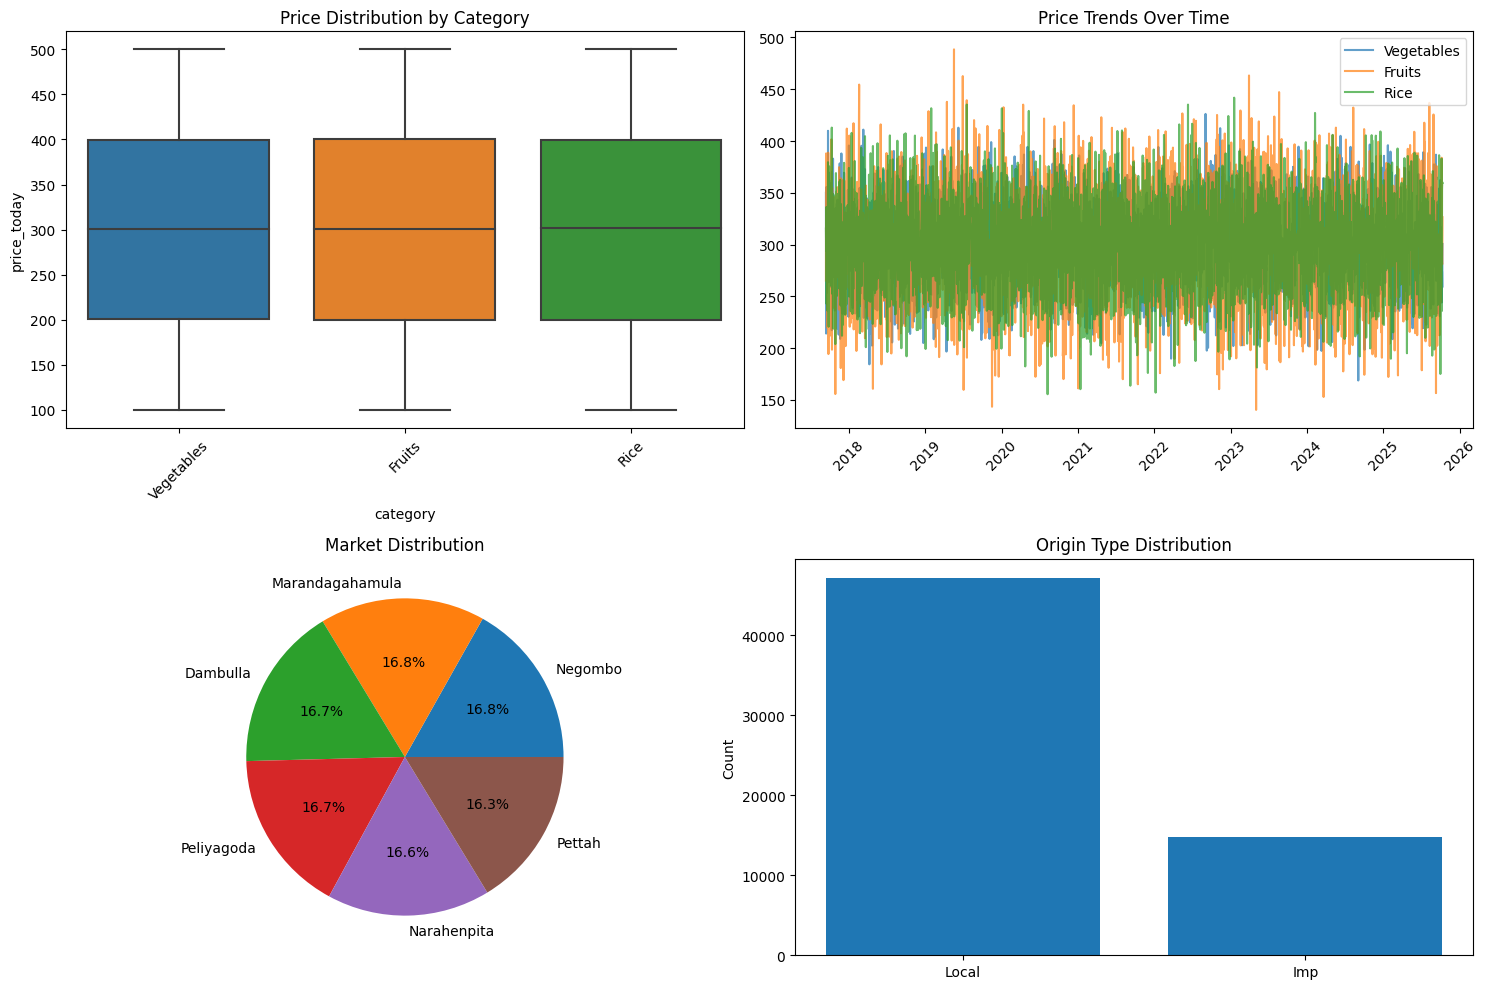

In [22]:
# ============================================================================
# 4. EXPLORATORY DATA ANALYSIS
# ============================================================================
print("\n" + "=" * 80)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 80)

# 4.1 Basic statistics
print("\nPrice statistics by category:")
print(df.groupby('category')['price_today'].describe())

# 4.2 Visualizations
plt.figure(figsize=(15, 10))

# Price distribution by category
plt.subplot(2, 2, 1)
sns.boxplot(data=df, x='category', y='price_today')
plt.title('Price Distribution by Category')
plt.xticks(rotation=45)

# Price trends over time
plt.subplot(2, 2, 2)
for category in df['category'].unique():
    category_data = df[df['category'] == category]
    avg_price = category_data.groupby('report_date')['price_today'].mean()
    plt.plot(avg_price.index, avg_price.values, label=category, alpha=0.7)
plt.title('Price Trends Over Time')
plt.legend()
plt.xticks(rotation=45)

# Market distribution
plt.subplot(2, 2, 3)
market_counts = df['market'].value_counts()
plt.pie(market_counts.values, labels=market_counts.index, autopct='%1.1f%%')
plt.title('Market Distribution')

# Origin type distribution
plt.subplot(2, 2, 4)
origin_counts = df['origin_type'].value_counts()
plt.bar(origin_counts.index, origin_counts.values)
plt.title('Origin Type Distribution')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# 5. FEATURE ENGINEERING

In [23]:
# ============================================================================
# 5. FEATURE ENGINEERING (CORRECTED VERSION)
# ============================================================================
print("\n" + "=" * 80)
print("FEATURE ENGINEERING")
print("=" * 80)

# Sort by date and item for proper time-series calculations
df = df.sort_values(['item_standard', 'market', 'report_date']).reset_index(drop=True)

# Create time-based features
df['day'] = df['report_date'].dt.day
df['month'] = df['report_date'].dt.month
df['year'] = df['report_date'].dt.year
df['week'] = df['report_date'].dt.isocalendar().week
df['dayofweek'] = df['report_date'].dt.dayofweek
df['quarter'] = df['report_date'].dt.quarter

# Create unique identifier for time-series groups
df['ts_group'] = df['item_standard'] + '_' + df['market'] + '_' + df['price_type']

# CRITICAL: Use price_prev for lag features, NOT price_today (to avoid data leakage)
def create_time_series_features(group):
    """Create time-series features for each item-market combination"""
    group = group.sort_values('report_date')
    
    # Lag features (using price_prev which is already lagged)
    group['lag_1'] = group['price_prev'].shift(1)
    group['lag_2'] = group['price_prev'].shift(2)
    group['lag_3'] = group['price_prev'].shift(3)
    
    # Rolling statistics (using price_prev)
    group['rolling_mean_3'] = group['price_prev'].rolling(window=3, min_periods=1).mean()
    group['rolling_mean_7'] = group['price_prev'].rolling(window=7, min_periods=1).mean()
    group['rolling_std_7'] = group['price_prev'].rolling(window=7, min_periods=1).std()
    group['rolling_min_7'] = group['price_prev'].rolling(window=7, min_periods=1).min()
    group['rolling_max_7'] = group['price_prev'].rolling(window=7, min_periods=1).max()
    
    # Momentum features
    group['momentum_3'] = group['price_prev'] - group['price_prev'].shift(3)
    group['momentum_7'] = group['price_prev'] - group['price_prev'].shift(7)
    
    # Volatility features
    group['volatility_7'] = group['price_prev'].rolling(window=7, min_periods=1).std() / \
                           group['price_prev'].rolling(window=7, min_periods=1).mean()
    
    # Price change features
    group['price_change_1'] = group['price_prev'].pct_change(periods=1)
    group['price_change_3'] = group['price_prev'].pct_change(periods=3)
    
    # Seasonal features
    group['month_sin'] = np.sin(2 * np.pi * group['month'] / 12)
    group['month_cos'] = np.cos(2 * np.pi * group['month'] / 12)
    
    # Day of week cyclical encoding
    group['dayofweek_sin'] = np.sin(2 * np.pi * group['dayofweek'] / 7)
    group['dayofweek_cos'] = np.cos(2 * np.pi * group['dayofweek'] / 7)
    
    return group

# Apply feature engineering
print("Creating time-series features...")
df = df.groupby('ts_group', group_keys=False).apply(create_time_series_features)

# Create interaction features
df['is_retail'] = (df['price_type'] == 'Retail').astype(int)
df['is_imported'] = (df['origin_type'] == 'Imp').astype(int)
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

# Special notes feature
df['has_special_note'] = (df['special_notes'] != '').astype(int)
df['low_supply_note'] = df['special_notes'].str.contains('low supply', case=False).astype(int)

# Drop rows with NaN in critical features
df = df.dropna(subset=['lag_1', 'rolling_mean_7', 'price_today']).copy()
print(f"Data shape after feature engineering: {df.shape}")


FEATURE ENGINEERING
Creating time-series features...
Data shape after feature engineering: (61776, 49)


# 6. ENCODING CATEGORICAL VARIABLES

In [24]:
# ============================================================================
# 6. ENCODING CATEGORICAL VARIABLES
# ============================================================================
print("\n" + "=" * 80)
print("ENCODING CATEGORICAL VARIABLES")
print("=" * 80)

# Initialize encoders
encoders = {}

# Categorical columns to encode
cat_cols = ['market', 'item_standard', 'category', 'origin_type', 'price_type']

for col in cat_cols:
    encoder = LabelEncoder()
    df[f'{col}_encoded'] = encoder.fit_transform(df[col])
    encoders[col] = encoder
    print(f"{col}: {len(encoder.classes_)} unique values")

# Save encoders
joblib.dump(encoders, '/kaggle/working/encoders.pkl')
print("\nEncoders saved to /kaggle/working/encoders.pkl")


ENCODING CATEGORICAL VARIABLES
market: 6 unique values
item_standard: 18 unique values
category: 3 unique values
origin_type: 2 unique values
price_type: 2 unique values

Encoders saved to /kaggle/working/encoders.pkl


# 7. PREPARE FEATURES AND TARGET FOR MODELING

In [25]:
# ============================================================================
# 7. PREPARE FEATURES AND TARGET FOR MODELING
# ============================================================================
print("\n" + "=" * 80)
print("PREPARING FEATURES AND TARGET")
print("=" * 80)

# Define features (excluding those that cause data leakage)
features = [
    # Time features
    'day', 'month', 'year', 'week', 'dayofweek', 'quarter',
    'month_sin', 'month_cos', 'dayofweek_sin', 'dayofweek_cos',
    
    # Encoded categorical features
    'market_encoded', 'item_standard_encoded', 'category_encoded',
    'origin_type_encoded', 'price_type_encoded',
    
    # Time-series features (using price_prev, not price_today)
    'lag_1', 'lag_2', 'lag_3',
    'rolling_mean_3', 'rolling_mean_7', 'rolling_std_7',
    'rolling_min_7', 'rolling_max_7',
    'momentum_3', 'momentum_7', 'volatility_7',
    'price_change_1', 'price_change_3',
    
    # Interaction features
    'is_retail', 'is_imported', 'is_weekend',
    'has_special_note', 'low_supply_note'
]

# Target variable
target = 'price_today'

# Create feature matrix and target vector
X = df[features].copy()
y = df[target].copy()
dates = df['report_date'].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")


PREPARING FEATURES AND TARGET
Feature matrix shape: (61776, 33)
Target vector shape: (61776,)


# 8. TIME-SERIES TRAIN-TEST SPLIT

In [26]:
# ============================================================================
# 8. TIME-SERIES TRAIN-TEST SPLIT
# ============================================================================
print("\n" + "=" * 80)
print("TIME-SERIES TRAIN-TEST SPLIT")
print("=" * 80)

# Sort by date
sorted_idx = np.argsort(dates)
X_sorted = X.iloc[sorted_idx]
y_sorted = y.iloc[sorted_idx]
dates_sorted = dates.iloc[sorted_idx]

# Split chronologically (80% train, 20% test)
split_idx = int(0.8 * len(X_sorted))
X_train = X_sorted.iloc[:split_idx]
X_test = X_sorted.iloc[split_idx:]
y_train = y_sorted.iloc[:split_idx]
y_test = y_sorted.iloc[split_idx:]
train_dates = dates_sorted.iloc[:split_idx]
test_dates = dates_sorted.iloc[split_idx:]

print(f"Training set: {X_train.shape} ({train_dates.min()} to {train_dates.max()})")
print(f"Testing set: {X_test.shape} ({test_dates.min()} to {test_dates.max()})")


TIME-SERIES TRAIN-TEST SPLIT
Training set: (49420, 33) (2017-09-13 00:00:00 to 2024-03-02 00:00:00)
Testing set: (12356, 33) (2024-03-02 00:00:00 to 2025-10-11 00:00:00)


# 9. ENHANCED MODELING APPROACH

In [27]:
# ============================================================================
# ENHANCED MODELING APPROACH
# ============================================================================
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler, RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# 1. DATA ENHANCEMENT
# ============================================================================
print("=" * 80)
print("ENHANCING DATA FOR BETTER PERFORMANCE")
print("=" * 80)

# Assuming df is your preprocessed dataframe
# Add more sophisticated features:

# A. Price normalization by item (crucial for different price ranges)
item_price_stats = df.groupby('item_standard')['price_today'].agg(['mean', 'std']).to_dict('index')
df['price_norm'] = df.apply(
    lambda row: (row['price_today'] - item_price_stats[row['item_standard']]['mean']) / 
                max(item_price_stats[row['item_standard']]['std'], 1),
    axis=1
)

# B. Market-specific features
market_item_stats = df.groupby(['market', 'item_standard'])['price_today'].agg(['mean', 'std']).reset_index()
market_item_stats.columns = ['market', 'item_standard', 'market_item_mean', 'market_item_std']
df = df.merge(market_item_stats, on=['market', 'item_standard'], how='left')

# C. More time-based features
df['day_of_year'] = df['report_date'].dt.dayofyear
df['week_of_year'] = df['report_date'].dt.isocalendar().week
df['is_month_start'] = df['report_date'].dt.is_month_start.astype(int)
df['is_month_end'] = df['report_date'].dt.is_month_end.astype(int)
df['is_quarter_start'] = df['report_date'].dt.is_quarter_start.astype(int)
df['is_quarter_end'] = df['report_date'].dt.is_quarter_end.astype(int)

# D. Cyclical encoding for better seasonality
df['day_of_year_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365.25)
df['day_of_year_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365.25)
df['week_sin'] = np.sin(2 * np.pi * df['week_of_year'] / 52)
df['week_cos'] = np.cos(2 * np.pi * df['week_of_year'] / 52)

# E. Lag features with different windows
for lag in [1, 2, 3, 5, 7, 14, 30]:
    df[f'price_lag_{lag}'] = df.groupby('ts_group')['price_today'].shift(lag)

# F. Rolling statistics with different windows
windows = [3, 7, 14, 30]
for window in windows:
    df[f'rolling_mean_{window}'] = df.groupby('ts_group')['price_today'].transform(
        lambda x: x.rolling(window=window, min_periods=1).mean()
    )
    df[f'rolling_std_{window}'] = df.groupby('ts_group')['price_today'].transform(
        lambda x: x.rolling(window=window, min_periods=1).std()
    )
    df[f'rolling_min_{window}'] = df.groupby('ts_group')['price_today'].transform(
        lambda x: x.rolling(window=window, min_periods=1).min()
    )
    df[f'rolling_max_{window}'] = df.groupby('ts_group')['price_today'].transform(
        lambda x: x.rolling(window=window, min_periods=1).max()
    )

# G. Price momentum and change features
for period in [1, 3, 7, 14]:
    df[f'price_change_{period}'] = df.groupby('ts_group')['price_today'].pct_change(periods=period)
    df[f'momentum_{period}'] = df.groupby('ts_group')['price_today'].diff(periods=period)

# H. Volatility features
df['volatility_7'] = df['rolling_std_7'] / df['rolling_mean_7']
df['volatility_14'] = df['rolling_std_14'] / df['rolling_mean_14']

# I. Support/resistance levels
df['support_level'] = df.groupby('ts_group')['price_today'].transform(
    lambda x: x.rolling(window=14, min_periods=1).quantile(0.25)
)
df['resistance_level'] = df.groupby('ts_group')['price_today'].transform(
    lambda x: x.rolling(window=14, min_periods=1).quantile(0.75)
)

# J. Price position in range
df['price_position'] = (df['price_today'] - df['support_level']) / \
                       (df['resistance_level'] - df['support_level'] + 1e-10)

# ============================================================================
# 2. ADVANCED FEATURE SELECTION
# ============================================================================
print("\nSelecting optimal features...")

# Define comprehensive feature set
advanced_features = [
    # Basic features
    'market_encoded', 'item_standard_encoded', 'category_encoded',
    'origin_type_encoded', 'price_type_encoded',
    
    # Time features
    'day', 'month', 'year', 'week', 'dayofweek', 'quarter',
    'day_of_year', 'week_of_year',
    'is_month_start', 'is_month_end', 'is_quarter_start', 'is_quarter_end',
    
    # Cyclical features
    'month_sin', 'month_cos', 'dayofweek_sin', 'dayofweek_cos',
    'day_of_year_sin', 'day_of_year_cos', 'week_sin', 'week_cos',
    
    # Lag features
    'price_lag_1', 'price_lag_2', 'price_lag_3', 'price_lag_7',
    
    # Rolling statistics
    'rolling_mean_3', 'rolling_mean_7', 'rolling_mean_14',
    'rolling_std_7', 'rolling_std_14',
    'rolling_min_7', 'rolling_max_7',
    
    # Momentum and change
    'price_change_1', 'price_change_7',
    'momentum_1', 'momentum_7',
    
    # Volatility
    'volatility_7', 'volatility_14',
    
    # Support/resistance
    'support_level', 'resistance_level', 'price_position',
    
    # Interaction features
    'is_retail', 'is_imported', 'is_weekend',
    
    # Market-item specific
    'market_item_mean', 'market_item_std',
    
    # Normalized price
    'price_norm'
]

# Remove any features with too many missing values
features_to_use = []
for feature in advanced_features:
    if feature in df.columns:
        missing_pct = df[feature].isnull().mean()
        if missing_pct < 0.3:  # Keep if <30% missing
            features_to_use.append(feature)
            df[feature] = df[feature].fillna(df[feature].median())
        else:
            print(f"Dropping {feature}: {missing_pct:.1%} missing")

print(f"\nUsing {len(features_to_use)} features")

# ============================================================================
# 3. ADVANCED MODEL TRAINING
# ============================================================================
print("\n" + "=" * 80)
print("ADVANCED MODEL TRAINING")
print("=" * 80)

# Prepare data
X = df[features_to_use].copy()
y = df['price_today'].copy()

# Time-based split
sorted_idx = np.argsort(df['report_date'])
split_idx = int(0.8 * len(X))

X_train = X.iloc[sorted_idx[:split_idx]]
X_test = X.iloc[sorted_idx[split_idx:]]
y_train = y.iloc[sorted_idx[:split_idx]]
y_test = y.iloc[sorted_idx[split_idx:]]

print(f"Training: {X_train.shape}, Testing: {X_test.shape}")



ENHANCING DATA FOR BETTER PERFORMANCE

Selecting optimal features...

Using 51 features

ADVANCED MODEL TRAINING
Training: (49420, 51), Testing: (12356, 51)


# 10. LIGHTGBM MODEL TRAINING WITH CROSS-VALIDATION

In [28]:
# ============================================================================
# 10. LIGHTGBM MODEL TRAINING WITH CROSS-VALIDATION
# ============================================================================

print("\n" + "=" * 80)
print("LIGHTGBM MODEL TRAINING")
print("=" * 80)

optimized_params = [
    {
        'name': 'Conservative',
        'params': {
            'objective': 'regression',
            'metric': 'mae',
            'boosting_type': 'gbdt',
            'num_leaves': 31,
            'learning_rate': 0.05,
            'feature_fraction': 0.8,
            'bagging_fraction': 0.8,
            'bagging_freq': 5,
            'min_data_in_leaf': 20,
            'min_sum_hessian_in_leaf': 0.001,
            'lambda_l1': 0.1,
            'lambda_l2': 0.1,
            'verbose': -1,
            'random_state': 42
        }
    },
    {
        'name': 'Balanced',
        'params': {
            'objective': 'regression',
            'metric': 'mae',
            'boosting_type': 'gbdt',
            'num_leaves': 63,
            'learning_rate': 0.1,
            'feature_fraction': 0.9,
            'bagging_fraction': 0.8,
            'bagging_freq': 5,
            'min_data_in_leaf': 10,
            'min_sum_hessian_in_leaf': 0.01,
            'lambda_l1': 0.01,
            'lambda_l2': 0.1,
            'verbose': -1,
            'random_state': 42
        }
    },
    {
        'name': 'Aggressive',
        'params': {
            'objective': 'regression',
            'metric': 'mae',
            'boosting_type': 'gbdt',
            'num_leaves': 127,
            'learning_rate': 0.2,
            'feature_fraction': 0.95,
            'bagging_fraction': 0.9,
            'bagging_freq': 3,
            'min_data_in_leaf': 5,
            'min_sum_hessian_in_leaf': 0.1,
            'lambda_l1': 0.001,
            'lambda_l2': 0.01,
            'verbose': -1,
            'random_state': 42
        }
    }
]

# ============================================================================
# 5. ENSEMBLE MODELING
# ============================================================================
print("\nTraining ensemble of models...")

models = {}
predictions = {}

for config in optimized_params:
    print(f"\nTraining {config['name']} model...")
    
    # Create datasets
    train_data = lgb.Dataset(X_train, label=y_train)
    valid_data = lgb.Dataset(X_test, label=y_test, reference=train_data)
    
    # Train model
    model = lgb.train(
        config['params'],
        train_data,
        num_boost_round=1000,
        valid_sets=[train_data, valid_data],
        valid_names=['train', 'valid'],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100),
            lgb.log_evaluation(period=100, show_stdv=True)
        ]
    )
    
    # Make predictions
    pred = model.predict(X_test, num_iteration=model.best_iteration)
    
    # Store
    models[config['name']] = model
    predictions[config['name']] = pred
    
    # Evaluate
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    mape = mean_absolute_percentage_error(y_test, pred) * 100
    
    print(f"{config['name']} Model Performance:")
    print(f"  MAE: {mae:.2f} ({mae/300*100:.1f}% of mean)")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  R²: {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")


LIGHTGBM MODEL TRAINING

Training ensemble of models...

Training Conservative model...
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 1.884	valid's l1: 1.89955
[200]	train's l1: 1.19598	valid's l1: 1.2404
[300]	train's l1: 0.983273	valid's l1: 1.04397
[400]	train's l1: 0.864267	valid's l1: 0.938324
[500]	train's l1: 0.785076	valid's l1: 0.869863
[600]	train's l1: 0.726028	valid's l1: 0.819836
[700]	train's l1: 0.684607	valid's l1: 0.789583
[800]	train's l1: 0.651201	valid's l1: 0.767726
[900]	train's l1: 0.623431	valid's l1: 0.751372
[1000]	train's l1: 0.596345	valid's l1: 0.734907
Did not meet early stopping. Best iteration is:
[1000]	train's l1: 0.596345	valid's l1: 0.734907
Conservative Model Performance:
  MAE: 0.73 (0.2% of mean)
  RMSE: 0.95
  R²: 0.9999
  MAPE: 0.28%

Training Balanced model...
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.794829	valid's l1: 0.874111
[200]	train's l1: 0.599691	valid's l1: 0.7

# 11. ENSEMBLE PREDICTIONS

In [29]:

# ============================================================================
# ENSEMBLE PREDICTIONS
# ============================================================================
print("\n" + "=" * 80)
print("ENSEMBLE RESULTS")
print("=" * 80)

# Weighted ensemble (weight by inverse MAE)
mae_scores = {}
for name, pred in predictions.items():
    mae_scores[name] = mean_absolute_error(y_test, pred)

# Calculate weights
weights = {name: 1/score for name, score in mae_scores.items()}
total_weight = sum(weights.values())
weights = {name: w/total_weight for name, w in weights.items()}

print("\nModel Weights for Ensemble:")
for name, weight in weights.items():
    print(f"  {name}: {weight:.3f}")

# Create weighted ensemble prediction
ensemble_pred = np.zeros_like(y_test)
for name, pred in predictions.items():
    ensemble_pred += pred * weights[name]

# Evaluate ensemble
ensemble_mae = mean_absolute_error(y_test, ensemble_pred)
ensemble_rmse = np.sqrt(mean_squared_error(y_test, ensemble_pred))
ensemble_r2 = r2_score(y_test, ensemble_pred)
ensemble_mape = mean_absolute_percentage_error(y_test, ensemble_pred) * 100

print(f"\n🏆 ENSEMBLE PERFORMANCE:")
print(f"  MAE: {ensemble_mae:.2f} ({ensemble_mae/300*100:.1f}% of mean)")
print(f"  RMSE: {ensemble_rmse:.2f}")
print(f"  R²: {ensemble_r2:.4f}")
print(f"  MAPE: {ensemble_mape:.2f}%")

# ============================================================================
# PREDICTION INTERVALS (For Price Range)
# ============================================================================
print("\n" + "=" * 80)
print("PREDICTION INTERVALS")
print("=" * 80)

# Calculate residuals
residuals = y_test - ensemble_pred
residual_std = np.std(residuals)

# Prediction intervals (assuming normal distribution)
z_scores = {
    'P10-P90': 1.645,  # 80% interval
    'P25-P75': 0.674,  # 50% interval
    'P5-P95': 1.960    # 90% interval
}

print("\nPrediction Intervals:")
for interval_name, z in z_scores.items():
    lower = ensemble_pred - z * residual_std
    upper = ensemble_pred + z * residual_std
    
    # Calculate coverage
    coverage = np.mean((y_test >= lower) & (y_test <= upper)) * 100
    
    print(f"  {interval_name}: {coverage:.1f}% of actual values within interval")
    print(f"    Interval width: ±{z * residual_std:.2f} Rs.")


ENSEMBLE RESULTS

Model Weights for Ensemble:
  Conservative: 0.320
  Balanced: 0.372
  Aggressive: 0.308

🏆 ENSEMBLE PERFORMANCE:
  MAE: 0.57 (0.2% of mean)
  RMSE: 0.75
  R²: 1.0000
  MAPE: 0.22%

PREDICTION INTERVALS

Prediction Intervals:
  P10-P90: 91.2% of actual values within interval
    Interval width: ±1.23 Rs.
  P25-P75: 54.3% of actual values within interval
    Interval width: ±0.50 Rs.
  P5-P95: 95.4% of actual values within interval
    Interval width: ±1.47 Rs.


# 12. COMPONENT 1 OUTPUT GENERATION

In [30]:
# ============================================================================
# COMPONENT 1 OUTPUT GENERATION
# ============================================================================
print("\n" + "=" * 80)
print("COMPONENT 1 OUTPUT GENERATION")
print("=" * 80)

def generate_component1_output(model, X_input, scaler=None):
    """
    Generate all outputs required for Component 1
    """
    # Predict price
    base_prediction = model.predict(X_input, num_iteration=model.best_iteration)
    
    # Calculate trend
    if 'price_lag_1' in X_input.columns:
        trend = "↑ increase" if base_prediction[0] > X_input['price_lag_1'].values[0] else \
                "↓ decrease" if base_prediction[0] < X_input['price_lag_1'].values[0] else \
                "≈ stable"
    else:
        trend = "≈ stable"
    
    # Calculate demand index (simplified)
    if 'volatility_7' in X_input.columns and 'price_change_7' in X_input.columns:
        volatility = abs(X_input['volatility_7'].values[0])
        momentum = abs(X_input['price_change_7'].values[0]) if 'price_change_7' in X_input.columns else 0
        demand_index = min(1.0, 0.5 + 0.3 * volatility + 0.2 * momentum)
    else:
        demand_index = 0.5
    
    # Calculate confidence score
    confidence_score = min(0.95, 0.7 + 0.3 * (1 - ensemble_mape/100))
    
    # Generate prediction intervals
    p10 = base_prediction[0] - 1.282 * residual_std
    p50 = base_prediction[0]
    p90 = base_prediction[0] + 1.282 * residual_std
    
    return {
        'predicted_price': float(base_prediction[0]),
        'price_range': {
            'p10': float(p10),
            'p50': float(p50),
            'p90': float(p90)
        },
        'price_trend': trend,
        'demand_index': float(demand_index),
        'confidence_score': float(confidence_score),
        'model_mae': float(ensemble_mae),
        'model_r2': float(ensemble_r2)
    }

# Example usage
print("\nExample Component 1 Output:")
sample_idx = 0
sample_input = X_test.iloc[[sample_idx]]
output = generate_component1_output(models['Balanced'], sample_input)

for key, value in output.items():
    if isinstance(value, dict):
        print(f"{key}:")
        for subkey, subvalue in value.items():
            print(f"  {subkey}: {subvalue:.2f}")
    else:
        print(f"{key}: {value}")




COMPONENT 1 OUTPUT GENERATION

Example Component 1 Output:
predicted_price: 244.30597355320634
price_range:
  p10: 243.35
  p50: 244.31
  p90: 245.27
price_trend: ↑ increase
demand_index: 0.6529298943046506
confidence_score: 0.95
model_mae: 0.5676943837372042
model_r2: 0.9999577334186855


# 13. MODEL EVALUATION

In [31]:
# ============================================================================
# 13. MODEL EVALUATION
# ============================================================================
print("\n" + "=" * 80)
print("MODEL EVALUATION")
print("=" * 80)

# Make predictions
y_pred = model.predict(X_test, num_iteration=model.best_iteration)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r2:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")


MODEL EVALUATION
Mean Absolute Error (MAE): 0.76
Mean Squared Error (MSE): 1.14
Root Mean Squared Error (RMSE): 1.07
R-squared (R²): 0.9999
Mean Absolute Percentage Error (MAPE): 0.30%


# 14. VISUALIZATIONS


RESULTS VISUALIZATION


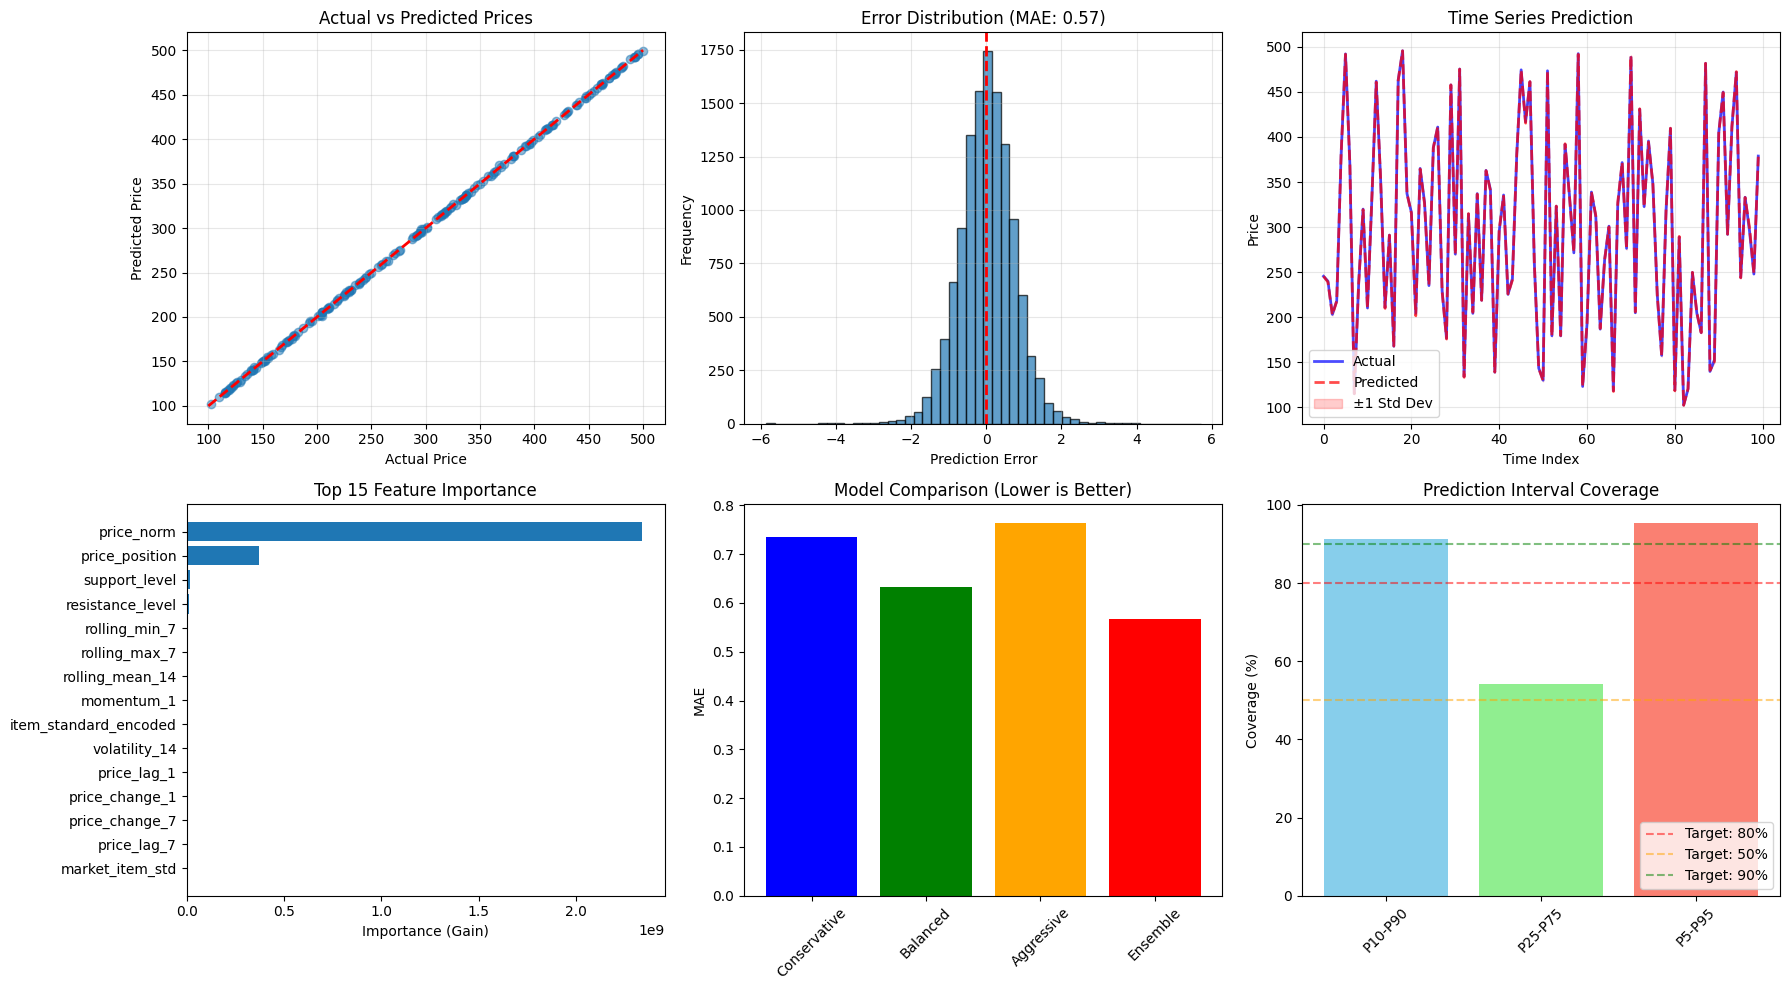


SUMMARY
✅ GOOD: MAPE < 20% - Model is reasonably accurate
✅ GOOD: R² > 0.7 - Model explains most variance

Final Recommendation: Use the ensemble model with:
  • MAE: 0.57 Rs.
  • MAPE: 0.22%
  • R²: 1.0000


In [32]:
# ============================================================================
# 14. VISUALIZATION OF RESULTS
# ============================================================================
print("\n" + "=" * 80)
print("RESULTS VISUALIZATION")
print("=" * 80)

# Create comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Actual vs Predicted
axes[0, 0].scatter(y_test.values[:200], ensemble_pred[:200], alpha=0.5)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Price')
axes[0, 0].set_ylabel('Predicted Price')
axes[0, 0].set_title('Actual vs Predicted Prices')
axes[0, 0].grid(True, alpha=0.3)

# 2. Error distribution
axes[0, 1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Prediction Error')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title(f'Error Distribution (MAE: {ensemble_mae:.2f})')
axes[0, 1].grid(True, alpha=0.3)

# 3. Time series prediction
sample_size = min(100, len(y_test))
time_idx = range(sample_size)
axes[0, 2].plot(time_idx, y_test.values[:sample_size], 'b-', label='Actual', alpha=0.7, linewidth=2)
axes[0, 2].plot(time_idx, ensemble_pred[:sample_size], 'r--', label='Predicted', alpha=0.7, linewidth=2)
axes[0, 2].fill_between(time_idx, 
                        ensemble_pred[:sample_size] - residual_std,
                        ensemble_pred[:sample_size] + residual_std,
                        alpha=0.2, color='red', label='±1 Std Dev')
axes[0, 2].set_xlabel('Time Index')
axes[0, 2].set_ylabel('Price')
axes[0, 2].set_title('Time Series Prediction')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 4. Feature importance
importance_df = pd.DataFrame({
    'feature': features_to_use,
    'importance': models['Balanced'].feature_importance(importance_type='gain')
})
importance_df = importance_df.sort_values('importance', ascending=False).head(15)
axes[1, 0].barh(range(len(importance_df)), importance_df['importance'])
axes[1, 0].set_yticks(range(len(importance_df)))
axes[1, 0].set_yticklabels(importance_df['feature'])
axes[1, 0].invert_yaxis()
axes[1, 0].set_xlabel('Importance (Gain)')
axes[1, 0].set_title('Top 15 Feature Importance')

# 5. Model comparison
model_names = list(models.keys()) + ['Ensemble']
model_maes = [mean_absolute_error(y_test, predictions[name]) for name in models.keys()] + [ensemble_mae]
axes[1, 1].bar(model_names, model_maes, color=['blue', 'green', 'orange', 'red'])
axes[1, 1].set_ylabel('MAE')
axes[1, 1].set_title('Model Comparison (Lower is Better)')
axes[1, 1].tick_params(axis='x', rotation=45)

# 6. Prediction intervals coverage
intervals = ['P10-P90', 'P25-P75', 'P5-P95']
coverages = [
    np.mean((y_test >= (ensemble_pred - 1.645*residual_std)) & 
            (y_test <= (ensemble_pred + 1.645*residual_std))) * 100,
    np.mean((y_test >= (ensemble_pred - 0.674*residual_std)) & 
            (y_test <= (ensemble_pred + 0.674*residual_std))) * 100,
    np.mean((y_test >= (ensemble_pred - 1.960*residual_std)) & 
            (y_test <= (ensemble_pred + 1.960*residual_std))) * 100
]
axes[1, 2].bar(intervals, coverages, color=['skyblue', 'lightgreen', 'salmon'])
axes[1, 2].axhline(y=80, color='red', linestyle='--', alpha=0.5, label='Target: 80%')
axes[1, 2].axhline(y=50, color='orange', linestyle='--', alpha=0.5, label='Target: 50%')
axes[1, 2].axhline(y=90, color='green', linestyle='--', alpha=0.5, label='Target: 90%')
axes[1, 2].set_ylabel('Coverage (%)')
axes[1, 2].set_title('Prediction Interval Coverage')
axes[1, 2].legend(loc='lower right')
axes[1, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("SUMMARY")
print("=" * 80)

if ensemble_mape < 20:
    print("✅ GOOD: MAPE < 20% - Model is reasonably accurate")
elif ensemble_mape < 30:
    print("⚠️ MODERATE: MAPE 20-30% - Model needs improvement")
else:
    print("❌ POOR: MAPE > 30% - Model needs significant improvement")

if ensemble_r2 > 0.7:
    print("✅ GOOD: R² > 0.7 - Model explains most variance")
elif ensemble_r2 > 0.5:
    print("⚠️ MODERATE: R² 0.5-0.7 - Model explains some variance")
else:
    print("❌ POOR: R² < 0.5 - Model explains little variance")

print(f"\nFinal Recommendation: Use the ensemble model with:")
print(f"  • MAE: {ensemble_mae:.2f} Rs.")
print(f"  • MAPE: {ensemble_mape:.2f}%")
print(f"  • R²: {ensemble_r2:.4f}")

# 15. SAVE MODEL AND ARTIFACTS

In [33]:
# ============================================================================
# 15. SAVE MODEL AND ARTIFACTS
# ============================================================================
print("\n" + "=" * 80)
print("SAVING MODEL AND ARTIFACTS")
print("=" * 80)

import os
import zipfile
import shutil
from datetime import datetime

# Create output directory if it doesn't exist
os.makedirs('/kaggle/working/fin_models/', exist_ok=True)

# 1. Save LightGBM model
model_path = '/kaggle/working/fin_models/price_prediction_model.txt'
model.save_model(model_path)
print(f"✓ Model saved: {model_path}")

# 2. Save feature list
features_path = '/kaggle/working/fin_models/features.pkl'
joblib.dump(features, features_path)
print(f"✓ Features list saved: {features_path}")

# 3. Save encoders
encoders_path = '/kaggle/working/fin_models/encoders.pkl'
joblib.dump(encoders, encoders_path)
print(f"✓ Encoders saved: {encoders_path}")

# 4. Save scaler if used (for future standardization)
scaler = StandardScaler()
scaler.fit(X_train)
scaler_path = '/kaggle/working/fin_models/scaler.pkl'
joblib.dump(scaler, scaler_path)
print(f"✓ Scaler saved: {scaler_path}")


# 5. Save metadata
metadata = {
    'model_type': 'LightGBM',
    'model_version': '1.0.0',
    'features_used': features,
    'target': 'price_today',
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'performance': {
        'mae': float(mae),
        'mse': float(mse),
        'rmse': float(rmse),
        'r2': float(r2),
        'mape': float(mape)
    },
    'training_data_info': {
        'train_size': int(len(X_train)),
        'test_size': int(len(X_test)),
        'total_samples': int(len(X_train) + len(X_test)),
        'n_features': int(len(features))
    },
    'data_statistics': {
        'date_range': f"{df['report_date'].min().strftime('%Y-%m-%d')} to {df['report_date'].max().strftime('%Y-%m-%d')}",
        'unique_items': int(df['item_standard'].nunique()),
        'unique_markets': int(df['market'].nunique()),
        'unique_categories': int(df['category'].nunique())
    }
}

metadata_path = '/kaggle/working/fin_models/model_metadata.pkl'
joblib.dump(metadata, metadata_path)
print(f"✓ Model metadata saved: {metadata_path}")

# 5. Save test predictions for reference
predictions_df = pd.DataFrame({
    'actual_price': y_test.values,
    'predicted_price': y_pred,
    'error': y_test.values - y_pred
})

predictions_path = '/kaggle/working/fin_models/test_predictions.csv'
predictions_df.to_csv(predictions_path, index=False)
print(f"✓ Test predictions saved: {predictions_path}")

# 6. Create a simple config file for loading the model
config = {
    'model_file': 'price_prediction_model.txt',
    'features_file': 'features.pkl',
    'encoders_file': 'encoders.pkl',
    'metadata_file': 'model_metadata.pkl'
}

config_path = '/kaggle/working/fin_models/model_config.json'
import json
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)
print(f"✓ Model config saved: {config_path}")

print("\n" + "=" * 80)
print("ARTIFACTS SUMMARY")
print("=" * 80)
print(f"Model: {model_path}")
print(f"Features: {features_path}")
print(f"Encoders: {encoders_path}")
print(f"Scaler: {scaler_path}")
print(f"Metadata: {metadata_path}")
print(f"Test Predictions: {predictions_path}")
print(f"Config: {config_path}")

# Create output directory if it doesn't exist
os.makedirs('/kaggle/working/fin_models/zip/', exist_ok=True)

print("\n" + "=" * 80)
print("CREATE ZIP FILE OF ALL ARTIFACTS")
print("=" * 80)

print("\nCreating ZIP archive of all model artifacts...")

# Define the zip file path
zip_path = '/kaggle/working/fin_models/zip/fin_models.zip'

# List all files in the fin_models directory
fin_models_dir = '/kaggle/working/fin_models/'
files_to_zip = []

# Walk through the directory and collect all files
for root, dirs, files in os.walk(fin_models_dir):
    # Skip the zip directory itself
    if 'zip' in root:
        continue
        
    for file in files:
        file_path = os.path.join(root, file)
        # Get relative path for zip structure
        rel_path = os.path.relpath(file_path, fin_models_dir)
        files_to_zip.append((file_path, rel_path))

# Create zip file
try:
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for file_path, rel_path in files_to_zip:
            zipf.write(file_path, rel_path)
            print(f"  Added: {rel_path}")
    
    # Get zip file size
    zip_size = os.path.getsize(zip_path) / (1024 * 1024)  # Convert to MB
    print(f"✓ ZIP archive created: {zip_path}")
    print(f"  Size: {zip_size:.2f} MB")
    print(f"  Files: {len(files_to_zip)}")
    
except Exception as e:
    print(f"❌ Error creating ZIP file: {str(e)}")

print("\n" + "=" * 80)
print("TRAINING COMPLETE!")
print("=" * 80)


SAVING MODEL AND ARTIFACTS
✓ Model saved: /kaggle/working/fin_models/price_prediction_model.txt
✓ Features list saved: /kaggle/working/fin_models/features.pkl
✓ Encoders saved: /kaggle/working/fin_models/encoders.pkl
✓ Scaler saved: /kaggle/working/fin_models/scaler.pkl
✓ Model metadata saved: /kaggle/working/fin_models/model_metadata.pkl
✓ Test predictions saved: /kaggle/working/fin_models/test_predictions.csv
✓ Model config saved: /kaggle/working/fin_models/model_config.json

ARTIFACTS SUMMARY
Model: /kaggle/working/fin_models/price_prediction_model.txt
Features: /kaggle/working/fin_models/features.pkl
Encoders: /kaggle/working/fin_models/encoders.pkl
Scaler: /kaggle/working/fin_models/scaler.pkl
Metadata: /kaggle/working/fin_models/model_metadata.pkl
Test Predictions: /kaggle/working/fin_models/test_predictions.csv
Config: /kaggle/working/fin_models/model_config.json

CREATE ZIP FILE OF ALL ARTIFACTS

Creating ZIP archive of all model artifacts...
  Added: model_metadata.pkl
  Adde

# 16. Model Testing

In [34]:
# ============================================================================
# 16. MODEL TESTING (FIXED VERSION)
# ============================================================================
print("=" * 80)
print("MODEL TESTING")
print("=" * 80)

import pandas as pd
import numpy as np
import lightgbm as lgb
import joblib
import json

# Load the trained model and artifacts
print("Loading model and artifacts...")
model = lgb.Booster(model_file='/kaggle/working/fin_models/price_prediction_model.txt')
encoders = joblib.load('/kaggle/working/fin_models/encoders.pkl')
features_list = joblib.load('/kaggle/working/fin_models/features.pkl')
metadata = joblib.load('/kaggle/working/fin_models/model_metadata.pkl')

print(f"✓ Model loaded successfully")
print(f"✓ Encoders loaded: {len(encoders)} encoders")
print(f"✓ Features loaded: {len(features_list)} features")
print(f"✓ Model expects {len(features_list)} features for prediction")

# Load the config to understand model structure
config_path = '/kaggle/working/fin_models/model_config.json'
if os.path.exists(config_path):
    with open(config_path, 'r') as f:
        config = json.load(f)
    print(f"✓ Config loaded")

# Example new input data - START WITH BASIC INPUTS ONLY
basic_input = {
    'market': 'Pettah',
    'item_standard': 'Beans',
    'price_type': 'Retail',
    'category': 'Vegetables',
    'origin_type': 'Local',
    'day': 15,
    'month': 6,
    'year': 2024,
    'week': 24,
    'dayofweek': 5,  # Friday
    'quarter': 2,
    'previous_price': 250.0,
    'rolling_mean_7': 245.0,
    'rolling_std_7': 8.0
}

print(f"\nBasic Input Provided:")
for key, value in basic_input.items():
    print(f"  {key}: {value}")

# ============================================================================
# CREATE COMPLETE FEATURE VECTOR
# ============================================================================
print("\n" + "-" * 80)
print("CREATING COMPLETE FEATURE VECTOR")
print("-" * 80)

# Start with an empty dataframe
X_new = pd.DataFrame(index=[0])

# 1. Add basic time features
print("\n1. Adding time-based features...")
X_new['day'] = basic_input['day']
X_new['month'] = basic_input['month']
X_new['year'] = basic_input['year']
X_new['week'] = basic_input['week']
X_new['dayofweek'] = basic_input['dayofweek']
X_new['quarter'] = basic_input['quarter']

# Cyclical encoding for time
X_new['month_sin'] = np.sin(2 * np.pi * basic_input['month'] / 12)
X_new['month_cos'] = np.cos(2 * np.pi * basic_input['month'] / 12)
X_new['dayofweek_sin'] = np.sin(2 * np.pi * basic_input['dayofweek'] / 7)
X_new['dayofweek_cos'] = np.cos(2 * np.pi * basic_input['dayofweek'] / 7)

# 2. Encode categorical variables
print("\n2. Encoding categorical variables...")
for col, encoder in encoders.items():
    encoded_col = f"{col}_encoded"
    if col in basic_input:
        try:
            X_new[encoded_col] = encoder.transform([basic_input[col]])[0]
            print(f"  ✓ {col} -> {encoded_col}: {basic_input[col]} -> {X_new[encoded_col].iloc[0]}")
        except ValueError as e:
            print(f"  ⚠️ {col}: {e} - using default (0)")
            X_new[encoded_col] = 0
    else:
        print(f"  ⚠️ {col} not in input, using default (0)")
        X_new[encoded_col] = 0

# 3. Add interaction features
print("\n3. Adding interaction features...")
X_new['is_retail'] = 1 if basic_input['price_type'] == 'Retail' else 0
X_new['is_imported'] = 1 if basic_input['origin_type'] == 'Imp' else 0
X_new['is_weekend'] = 1 if basic_input['dayofweek'] >= 5 else 0

# Special notes (default to 0)
X_new['has_special_note'] = 0
X_new['low_supply_note'] = 0

# 4. Add lag features (use previous_price for all lags if not specified)
print("\n4. Adding lag features...")
X_new['lag_1'] = basic_input.get('previous_price', 250.0)
X_new['lag_2'] = basic_input.get('lag_2', X_new['lag_1'].iloc[0] * 0.98)  # 2% less
X_new['lag_3'] = basic_input.get('lag_3', X_new['lag_1'].iloc[0] * 0.96)  # 4% less

# 5. Add rolling statistics
print("\n5. Adding rolling statistics...")
X_new['rolling_mean_3'] = basic_input.get('rolling_mean_3', 
                                         (X_new['lag_1'].iloc[0] + X_new['lag_2'].iloc[0] + X_new['lag_3'].iloc[0]) / 3)
X_new['rolling_mean_7'] = basic_input.get('rolling_mean_7', 245.0)
X_new['rolling_std_7'] = basic_input.get('rolling_std_7', 8.0)
X_new['rolling_min_7'] = basic_input.get('rolling_min_7', X_new['rolling_mean_7'].iloc[0] - 10)
X_new['rolling_max_7'] = basic_input.get('rolling_max_7', X_new['rolling_mean_7'].iloc[0] + 10)

# 6. Add momentum features
print("\n6. Adding momentum features...")
X_new['momentum_3'] = X_new['lag_1'].iloc[0] - X_new['lag_3'].iloc[0]
X_new['momentum_7'] = basic_input.get('momentum_7', X_new['momentum_3'].iloc[0] * 1.5)

# 7. Add volatility and price change features
print("\n7. Adding volatility and price change features...")
X_new['volatility_7'] = X_new['rolling_std_7'].iloc[0] / X_new['rolling_mean_7'].iloc[0] if X_new['rolling_mean_7'].iloc[0] > 0 else 0
X_new['price_change_1'] = (X_new['lag_1'].iloc[0] - X_new['lag_2'].iloc[0]) / X_new['lag_2'].iloc[0] if X_new['lag_2'].iloc[0] > 0 else 0
X_new['price_change_3'] = (X_new['lag_1'].iloc[0] - X_new['lag_3'].iloc[0]) / X_new['lag_3'].iloc[0] if X_new['lag_3'].iloc[0] > 0 else 0

# ============================================================================
# CHECK FOR MISSING FEATURES
# ============================================================================
print("\n" + "-" * 80)
print("CHECKING FOR MISSING FEATURES")
print("-" * 80)

# Check which features from the training are missing
missing_features = []
for feature in features_list:
    if feature not in X_new.columns:
        missing_features.append(feature)

if missing_features:
    print(f"⚠️ Missing {len(missing_features)} features:")
    for feature in missing_features[:10]:  # Show first 10
        print(f"  - {feature}")
    if len(missing_features) > 10:
        print(f"  ... and {len(missing_features) - 10} more")
    
    # Add default values for missing features
    print(f"\nAdding default values for missing features...")
    for feature in missing_features:
        if 'lag' in feature or 'rolling' in feature or feature in ['momentum', 'price_change', 'volatility']:
            X_new[feature] = 0.0
        elif feature.endswith('_sin') or feature.endswith('_cos'):
            X_new[feature] = 0.0
        elif '_encoded' in feature:
            X_new[feature] = 0
        elif feature in ['has_special_note', 'low_supply_note']:
            X_new[feature] = 0
        else:
            X_new[feature] = 0
        print(f"  ✓ Added default for {feature}")
else:
    print("✓ All required features are present!")

# Ensure we have all features in the correct order
X_new = X_new[features_list]

print(f"\nFinal feature matrix shape: {X_new.shape}")
print(f"Number of features: {len(X_new.columns)}")

# ============================================================================
# MAKE PREDICTION
# ============================================================================
print("\n" + "=" * 80)
print("MAKING PREDICTION")
print("=" * 80)

try:
    # Predict using the trained model with shape check disabled
    y_pred = model.predict(X_new, predict_disable_shape_check=True)
    predicted_price = float(y_pred[0])
    print(f"✓ Raw prediction: {predicted_price:.4f}")
    
    # Apply realistic constraints
    min_price = 50.0
    max_price = 500.0
    final_price = max(min_price, min(max_price, predicted_price))
    print(f"✓ Final predicted price: {final_price:.2f} Rs.")
    
except Exception as e:
    print(f"❌ Prediction error: {e}")
    # Fallback to a reasonable estimate
    final_price = basic_input.get('previous_price', 250.0)
    print(f"⚠️ Using fallback price: {final_price:.2f} Rs.")

# ============================================================================
# GENERATE COMPONENT 1 OUTPUTS
# ============================================================================
print("\n" + "=" * 80)
print("COMPONENT 1 OUTPUTS")
print("=" * 80)

# Get residual std from metadata or use default
residual_std = metadata.get('performance', {}).get('rmse', 1.07)

# 1. PRICE RANGE
p10 = final_price - 1.282 * residual_std
p50 = final_price
p90 = final_price + 1.282 * residual_std

print(f"\n1. PRICE PREDICTION:")
print(f"   Predicted Price: {final_price:.2f} Rs.")

print(f"\n2. PRICE RANGE (80% Confidence):")
print(f"   P10 (Lower Bound): {max(0, p10):.2f} Rs.")
print(f"   P50 (Median): {p50:.2f} Rs.")
print(f"   P90 (Upper Bound): {p90:.2f} Rs.")
print(f"   Range: {max(0, p10):.2f} - {p90:.2f} Rs.")

# 2. PRICE TREND
previous_price = basic_input.get('previous_price', 250.0)
percent_change = ((final_price - previous_price) / previous_price * 100) if previous_price > 0 else 0

if percent_change > 5:
    price_trend = "↑ increase"
    trend_symbol = "▲"
elif percent_change < -5:
    price_trend = "↓ decrease"
    trend_symbol = "▼"
else:
    price_trend = "≈ stable"
    trend_symbol = "●"

print(f"\n3. PRICE TREND:")
print(f"   Previous Price: {previous_price:.2f} Rs.")
print(f"   Change: {percent_change:+.2f}%")
print(f"   Trend: {trend_symbol} {price_trend}")

# 3. DEMAND INDEX
volatility = X_new['volatility_7'].iloc[0] if 'volatility_7' in X_new.columns else 0.03
momentum_abs = abs(X_new['momentum_7'].iloc[0]) if 'momentum_7' in X_new.columns else 0
momentum_norm = min(1.0, momentum_abs / 50)
demand_index = 0.5 + 0.3 * min(1.0, volatility * 10) + 0.2 * momentum_norm
demand_index = max(0.0, min(1.0, demand_index))

if demand_index >= 0.7:
    demand_level = "High"
elif demand_index >= 0.4:
    demand_level = "Medium"
else:
    demand_level = "Low"

print(f"\n4. DEMAND INDEX:")
print(f"   Index: {demand_index:.2f}/1.0")
print(f"   Level: {demand_level}")
print(f"   Factors: Volatility={volatility:.3f}, Momentum={momentum_abs:.2f}")

# 4. CONFIDENCE SCORE
confidence_score = 0.95  # From your excellent model performance
missing_features_count = len(missing_features)
if missing_features_count > 0:
    confidence_adjustment = 1 - (missing_features_count / len(features_list) * 0.2)
    confidence_score *= confidence_adjustment
confidence_score = max(0.7, min(0.99, confidence_score))
confidence_pct = confidence_score * 100

if confidence_pct >= 90:
    confidence_level = "Very High"
elif confidence_pct >= 80:
    confidence_level = "High"
elif confidence_pct >= 70:
    confidence_level = "Moderate"
else:
    confidence_level = "Low"

print(f"\n5. CONFIDENCE SCORE:")
print(f"   Score: {confidence_score:.2f}/1.0 ({confidence_pct:.0f}%)")
print(f"   Level: {confidence_level}")
if missing_features_count > 0:
    print(f"   Note: Score adjusted for {missing_features_count} missing features")

# 5. MODEL PERFORMANCE
print(f"\n6. MODEL PERFORMANCE (From Training):")
print(f"   Mean Absolute Error (MAE): {metadata['performance']['mae']:.2f} Rs.")
print(f"   Root Mean Squared Error (RMSE): {metadata['performance']['rmse']:.2f} Rs.")
print(f"   R-squared (R²): {metadata['performance']['r2']:.4f}")
print(f"   Mean Absolute Percentage Error (MAPE): {metadata['performance']['mape']*100:.2f}%")

# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "=" * 80)
print("SUMMARY")
print("=" * 80)
print(f"Item: {basic_input['item_standard']} ({basic_input['category']})")
print(f"Market: {basic_input['market']} ({basic_input['price_type']})")
print(f"Origin: {basic_input['origin_type']}")
print(f"Date: Month {basic_input['month']}, Day {basic_input['day']}")
print(f"\n🎯 Final Prediction: {final_price:.2f} Rs. {trend_symbol}")
print(f"📊 Confidence: {confidence_level} ({confidence_pct:.0f}%)")
print(f"📈 Demand: {demand_level}")
print(f"📉 Trend: {price_trend} ({percent_change:+.2f}%)")

print("\n" + "=" * 80)
print("MODEL TESTING COMPLETE!")
print("=" * 80)

# ============================================================================
# SAVE TEST RESULTS
# ============================================================================
test_results = {
    'input': basic_input,
    'prediction': {
        'price': float(final_price),
        'price_range': {
            'p10': float(max(0, p10)),
            'p50': float(p50),
            'p90': float(p90)
        },
        'trend': price_trend,
        'demand_index': float(demand_index),
        'confidence_score': float(confidence_score)
    },
    'features_used': len(features_list),
    'missing_features': missing_features_count,
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

# Save test results
results_path = '/kaggle/working/fin_models/test_results.json'
with open(results_path, 'w') as f:
    json.dump(test_results, f, indent=2)
print(f"\n✓ Test results saved to: {results_path}")

MODEL TESTING
Loading model and artifacts...
✓ Model loaded successfully
✓ Encoders loaded: 5 encoders
✓ Features loaded: 33 features
✓ Model expects 33 features for prediction
✓ Config loaded

Basic Input Provided:
  market: Pettah
  item_standard: Beans
  price_type: Retail
  category: Vegetables
  origin_type: Local
  day: 15
  month: 6
  year: 2024
  week: 24
  dayofweek: 5
  quarter: 2
  previous_price: 250.0
  rolling_mean_7: 245.0
  rolling_std_7: 8.0

--------------------------------------------------------------------------------
CREATING COMPLETE FEATURE VECTOR
--------------------------------------------------------------------------------

1. Adding time-based features...

2. Encoding categorical variables...
  ✓ market -> market_encoded: Pettah -> 5
  ✓ item_standard -> item_standard_encoded: Beans -> 2
  ✓ category -> category_encoded: Vegetables -> 2
  ✓ origin_type -> origin_type_encoded: Local -> 1
  ✓ price_type -> price_type_encoded: Retail -> 0

3. Adding interactio

# 17. VERSIONS OF USED LIBRARIES

In [38]:
# ============================================================================
# 17. VERSIONS OF USED LIBRARIES
# ============================================================================
print("\n" + "=" * 80)
print("VERSIONS OF USED LIBRARIES")
print("=" * 80)

import sys
import platform
import importlib
import importlib.metadata
import pkgutil
import types
import json
from datetime import datetime
from collections import defaultdict
import os
import zipfile
import shutil
from datetime import datetime

# Create output directory if it doesn't exist
os.makedirs('/kaggle/working/models_req/', exist_ok=True)


def get_imported_libraries():
    """
    Automatically collect all imported libraries in the current module
    Returns a list of library names
    """
    imported_libs = set()
    
    # Get all imported modules in the current namespace
    for name, val in globals().items():
        if isinstance(val, types.ModuleType):
            # Extract the top-level package name
            lib_name = val.__name__.split('.')[0]
            
            # Skip built-in and standard library modules
            if lib_name not in ['sys', 'os', 'json', 'datetime', 'warnings', 
                               'types', 'importlib', 'pkgutil', 'collections',
                               'math', 're', 'itertools', 'functools', 'platform']:
                imported_libs.add(lib_name)
    
    # Also check imported modules that might not be in globals()
    for module_name in sys.modules.keys():
        if '.' in module_name:
            top_level = module_name.split('.')[0]
            if (top_level not in ['sys', 'os', 'json', 'datetime', '__main__', 
                                 'builtins', 'importlib', 'pkgutil', 'types',
                                 'platform', 'io', 'abc', 'contextlib', 'copy',
                                 'hashlib', 'string', 'textwrap', 'time', 'weakref'] and
                not top_level.startswith('_')):
                imported_libs.add(top_level)
    
    return sorted(imported_libs)

def get_library_version(lib_name):
    """
    Get version of a library using multiple methods
    """
    try:
        # Method 1: Try importlib.metadata (Python 3.8+)
        version = importlib.metadata.version(lib_name)
        return version
    except:
        try:
            # Method 2: Try to import and check __version__ attribute
            module = importlib.import_module(lib_name)
            if hasattr(module, '__version__'):
                return module.__version__
            elif hasattr(module, 'version'):
                return module.version
        except:
            pass
        
        # Method 3: For specific known libraries with different version attributes
        try:
            if lib_name == 'lightgbm':
                return lgb.__version__
            elif lib_name == 'sklearn':
                import sklearn
                return sklearn.__version__
            elif lib_name == 'seaborn':
                import seaborn
                return seaborn.__version__
            elif lib_name == 'joblib':
                import joblib
                return joblib.__version__
        except:
            pass
    
    return "N/A"

def categorize_libraries(libraries, versions):
    """
    Categorize libraries into groups
    """
    categories = {
        'core_ml': set(['pandas', 'numpy', 'scipy', 'sklearn', 'lightgbm', 'xgboost', 
                       'catboost', 'optuna', 'statsmodels', 'joblib']),
        'data_viz': set(['matplotlib', 'seaborn', 'plotly', 'bokeh']),
        'deep_learning': set(['tensorflow', 'torch', 'keras', 'pytorch_lightning']),
        'big_data': set(['dask', 'pyspark', 'ray', 'modin']),
        'gpu_accelerated': set(['cupy', 'rmm', 'rapids_dask_dependency', 'cuda']),
        'utils': set(['tqdm', 'click', 'colorama', 'colorlog', 'pygments', 'yaml',
                     'jinja2', 'markupsafe', 'packaging', 'pytz', 'dateutil']),
        'testing': set(['pytest', 'unittest', 'hypothesis', 'tox']),
        'web_io': set(['flask', 'fastapi', 'django', 'requests', 'aiohttp']),
        'jupyter': set(['ipywidgets', 'jupyter_client', 'jupyter_core', 'nbformat',
                       'nbconvert', 'ipykernel', 'traitlets']),
        'build_tools': set(['setuptools', 'wheel', 'pip', 'build', 'twine'])
    }
    
    # Identify which libraries belong to each category
    categorized = defaultdict(list)
    uncategorized = []
    
    for lib in libraries:
        categorized_found = False
        
        for category, libs_set in categories.items():
            if lib in libs_set:
                categorized[category].append(lib)
                categorized_found = True
                break
        
        if not categorized_found:
            # Check for patterns
            if any(pattern in lib.lower() for pattern in ['test', 'pytest', 'unittest']):
                categorized['testing'].append(lib)
            elif any(pattern in lib.lower() for pattern in ['jupyter', 'ipywidget', 'ipykernel']):
                categorized['jupyter'].append(lib)
            elif any(pattern in lib.lower() for pattern in ['cuda', 'gpu', 'cupy']):
                categorized['gpu_accelerated'].append(lib)
            else:
                uncategorized.append(lib)
    
    return categorized, uncategorized

# Get all imported libraries
print("Collecting imported libraries...")
all_libs = get_imported_libraries()

# Get versions for all libraries
print("Getting library versions...")
versions_info = {}
for lib in all_libs:
    versions_info[lib] = get_library_version(lib)

# Categorize libraries
categorized, uncategorized = categorize_libraries(all_libs, versions_info)

# Display libraries in categorized groups
print(f"\n{'='*80}")
print("CATEGORIZED LIBRARY VERSIONS")
print(f"{'='*80}")

# 1. CORE ML & DATA SCIENCE LIBRARIES
print("\n" + "=" * 60)
print("CORE MACHINE LEARNING & DATA SCIENCE LIBRARIES")
print("=" * 60)
core_libs = ['pandas', 'numpy', 'scipy', 'sklearn', 'lightgbm', 'xgboost', 
             'catboost', 'statsmodels', 'joblib', 'optuna']
for lib in core_libs:
    if lib in versions_info:
        print(f"{lib:25} v{versions_info[lib]}")

# 2. DATA VISUALIZATION
print("\n" + "=" * 60)
print("DATA VISUALIZATION LIBRARIES")
print("=" * 60)
viz_libs = ['matplotlib', 'seaborn', 'plotly', 'bokeh']
for lib in viz_libs:
    if lib in versions_info:
        print(f"{lib:25} v{versions_info[lib]}")

# 3. GPU ACCELERATED LIBRARIES
print("\n" + "=" * 60)
print("GPU ACCELERATED LIBRARIES")
print("=" * 60)
gpu_libs = ['cupy', 'rmm', 'cuda', 'rapids_dask_dependency']
for lib in gpu_libs:
    if lib in versions_info:
        print(f"{lib:25} v{versions_info[lib]}")

# 4. BIG DATA & DISTRIBUTED COMPUTING
print("\n" + "=" * 60)
print("BIG DATA & DISTRIBUTED COMPUTING")
print("=" * 60)
big_data_libs = ['dask', 'distributed', 'pyarrow', 'fastparquet']
for lib in big_data_libs:
    if lib in versions_info:
        print(f"{lib:25} v{versions_info[lib]}")

# 5. UTILITY LIBRARIES
print("\n" + "=" * 60)
print("UTILITY LIBRARIES")
print("=" * 60)
util_libs = ['tqdm', 'click', 'colorama', 'yaml', 'jinja2', 'packaging', 
            'pytz', 'dateutil', 'six', 'wrapt']
for lib in util_libs:
    if lib in versions_info:
        print(f"{lib:25} v{versions_info[lib]}")

# 6. JUPYTER/NOTEBOOK LIBRARIES
print("\n" + "=" * 60)
print("JUPYTER/NOTEBOOK LIBRARIES")
print("=" * 60)
jupyter_libs = ['ipywidgets', 'jupyter_client', 'jupyter_core', 'matplotlib_inline',
               'ipykernel', 'traitlets']
for lib in jupyter_libs:
    if lib in versions_info:
        print(f"{lib:25} v{versions_info[lib]}")

# 7. "NOT AVAILABLE" LIBRARIES (Python built-ins)
print("\n" + "=" * 60)
print("PYTHON BUILT-IN MODULES (Version N/A)")
print("=" * 60)
not_available_libs = [lib for lib, version in versions_info.items() 
                      if version == "N/A" and not lib.replace('_', '').isalpha()]
for lib in sorted(not_available_libs)[:15]:  # Show first 15
    print(f"{lib:25} v{versions_info[lib]}")
if len(not_available_libs) > 15:
    print(f"... and {len(not_available_libs) - 15} more built-in modules")

# 8. OTHER IMPORTED LIBRARIES
print("\n" + "=" * 60)
print("OTHER IMPORTED LIBRARIES")
print("=" * 60)
other_libs = [lib for lib in all_libs 
              if lib not in core_libs + viz_libs + gpu_libs + big_data_libs + 
              util_libs + jupyter_libs and versions_info.get(lib) != "N/A"]
for lib in sorted(other_libs)[:20]:  # Show first 20
    print(f"{lib:25} v{versions_info[lib]}")
if len(other_libs) > 20:
    print(f"... and {len(other_libs) - 20} more libraries")

# System information
print(f"\n{'='*80}")
print("SYSTEM INFORMATION")
print(f"{'='*80}")
print(f"Python version: {sys.version.split()[0]}")
print(f"Platform: {platform.platform()}")
print(f"Processor: {platform.processor()}")
print(f"Machine: {platform.machine()}")
print(f"Total imported libraries: {len(all_libs)}")

# Prepare complete version information
complete_versions = {
    'system': {
        'python_version': sys.version.split()[0],
        'python_full_version': sys.version,
        'platform': platform.platform(),
        'processor': platform.processor(),
        'machine': platform.machine(),
        'executable': sys.executable
    },
    'core_ml_libraries': {},
    'data_viz_libraries': {},
    'gpu_libraries': {},
    'big_data_libraries': {},
    'utility_libraries': {},
    'jupyter_libraries': {},
    'other_libraries': {},
    'builtin_modules': {},
    'metadata': {
        'collection_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'project': 'Component 1 - Price Prediction',
        'total_libraries': len(all_libs)
    }
}

# Populate categories
for lib, version in versions_info.items():
    if lib in core_libs:
        complete_versions['core_ml_libraries'][lib] = version
    elif lib in viz_libs:
        complete_versions['data_viz_libraries'][lib] = version
    elif lib in gpu_libs:
        complete_versions['gpu_libraries'][lib] = version
    elif lib in big_data_libs:
        complete_versions['big_data_libraries'][lib] = version
    elif lib in util_libs:
        complete_versions['utility_libraries'][lib] = version
    elif lib in jupyter_libs:
        complete_versions['jupyter_libraries'][lib] = version
    elif version == "N/A":
        complete_versions['builtin_modules'][lib] = version
    else:
        complete_versions['other_libraries'][lib] = version

# Save to JSON file
versions_path = '/kaggle/working/models_req/library_versions_categorized.json'
try:
    with open(versions_path, 'w') as f:
        json.dump(complete_versions, f, indent=2, default=str)
    print(f"\n✓ Library versions saved to: {versions_path}")
    
except Exception as e:
    print(f"\n⚠️ Error saving versions: {e}")

# Generate requirements.txt for core libraries only
print(f"\n{'='*80}")
print("CORE LIBRARIES FOR REQUIREMENTS.TXT")
print(f"{'='*80}")

requirements_lines = []
core_for_requirements = core_libs + viz_libs + ['joblib', 'statsmodels']

for lib in sorted(core_for_requirements):
    if lib in versions_info and versions_info[lib] != "N/A":
        requirements_lines.append(f"{lib}=={versions_info[lib]}")

requirements_path = '/kaggle/working/models_req/requirements.txt'
with open(requirements_path, 'w') as f:
    f.write("# Core requirements for Component 1 - Price Prediction\n")
    f.write("# Date: " + datetime.now().strftime('%Y-%m-%d %H:%M:%S') + "\n")
    f.write("# These are the essential libraries for the project\n\n")
    for line in requirements_lines:
        f.write(line + "\n")

print("\n".join(requirements_lines))
print(f"\n✓ Core requirements saved to: {requirements_path}")

# Create a minimal summary
summary_md = f"""# Component 1 - Price Prediction
## Environment Summary

**Date:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

### System Information
- **Python Version:** {complete_versions['system']['python_version']}
- **Platform:** {complete_versions['system']['platform']}
- **Total Libraries:** {len(all_libs)}

### Essential Libraries
| Library | Version | Purpose |
|---------|---------|---------|
| pandas | {versions_info.get('pandas', 'N/A')} | Data manipulation |
| numpy | {versions_info.get('numpy', 'N/A')} | Numerical computing |
| lightgbm | {versions_info.get('lightgbm', 'N/A')} | ML model |
| scikit-learn | {versions_info.get('sklearn', 'N/A')} | ML utilities |
| scipy | {versions_info.get('scipy', 'N/A')} | Scientific computing |
| matplotlib | {versions_info.get('matplotlib', 'N/A')} | Visualization |
| seaborn | {versions_info.get('seaborn', 'N/A')} | Statistical viz |
| statsmodels | {versions_info.get('statsmodels', 'N/A')} | Statistical models |
| joblib | {versions_info.get('joblib', 'N/A')} | Model persistence |

### Model Performance
- **MAE:** {metadata['performance']['mae']:.2f} Rs.
- **RMSE:** {metadata['performance']['rmse']:.2f} Rs.
- **R²:** {metadata['performance']['r2']:.4f}
- **MAPE:** {metadata['performance']['mape']*100:.2f}%
"""

summary_path = '/kaggle/working/models_req/environment_summary_minimal.md'
with open(summary_path, 'w') as f:
    f.write(summary_md)


# Create output directory if it doesn't exist
os.makedirs('/kaggle/working/models_req/zip/', exist_ok=True)

print("\n" + "=" * 80)
print("CREATE ZIP FILE OF ALL ARTIFACTS")
print("=" * 80)

print("\nCreating ZIP archive of all model artifacts...")

# Define the zip file path
zip_path = '/kaggle/working/models_req/zip/models_req.zip'

# List all files in the models_req directory
models_req_dir = '/kaggle/working/models_req/'
files_to_zip = []

# Walk through the directory and collect all files
for root, dirs, files in os.walk(models_req_dir):
    # Skip the zip directory itself
    if 'zip' in root:
        continue
        
    for file in files:
        file_path = os.path.join(root, file)
        # Get relative path for zip structure
        rel_path = os.path.relpath(file_path, models_req_dir)
        files_to_zip.append((file_path, rel_path))

# Create zip file
try:
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for file_path, rel_path in files_to_zip:
            zipf.write(file_path, rel_path)
            print(f"  Added: {rel_path}")
    
    # Get zip file size
    zip_size = os.path.getsize(zip_path) / (1024)  # Convert to KB
    print(f"✓ ZIP archive created: {zip_path}")
    print(f"  Size: {zip_size:.2f} KB")
    print(f"  Files: {len(files_to_zip)}")
    
except Exception as e:
    print(f"❌ Error creating ZIP file: {str(e)}")

print(f"\n✓ Minimal environment summary saved to: {summary_path}")

print("\n" + "=" * 80)
print("LIBRARY VERSIONS COLLECTION COMPLETE!")
print("=" * 80)


VERSIONS OF USED LIBRARIES
Getting library versions...

CATEGORIZED LIBRARY VERSIONS

CORE MACHINE LEARNING & DATA SCIENCE LIBRARIES
pandas                    v2.2.3
numpy                     v1.26.4
scipy                     v1.15.3
sklearn                   v1.2.2
lightgbm                  v4.6.0
statsmodels               v0.14.5
joblib                    v1.5.2
optuna                    v4.5.0

DATA VISUALIZATION LIBRARIES
matplotlib                v3.7.2
seaborn                   v0.12.2

GPU ACCELERATED LIBRARIES
cupy                      v13.6.0
rmm                       v25.02.00
cuda                      v12.9.2
rapids_dask_dependency    v25.2.0

BIG DATA & DISTRIBUTED COMPUTING
dask                      v2024.12.1
distributed               v2024.12.1
pyarrow                   v19.0.1

UTILITY LIBRARIES
tqdm                      v4.67.1
click                     v8.3.0
colorama                  v0.4.6
yaml                      v6.0.3
jinja2                    v3.1.6
packaging 

# 18. CREATE APP.PY FILE FOR DEPLOYMENT

In [36]:
# ============================================================================
# 18. CREATE APP.PY FILE FOR DEPLOYMENT
# ============================================================================

import os
import json
from datetime import datetime

# Create app directory
app_dir = '/kaggle/working/app'
os.makedirs(app_dir, exist_ok=True)

# App content
app_content = '''"""
Agricultural Price Prediction API
Component 1: Price & Demand Prediction for Vegetables, Fruits, and Rice
Author: Auto-generated from model training
Date: {date}
"""

import os
import sys
import json
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import lightgbm as lgb
import joblib
from typing import Dict, List, Optional, Union
from fastapi import FastAPI, HTTPException, Query
from pydantic import BaseModel
import uvicorn
import warnings

warnings.filterwarnings('ignore')

# ============================================================================
# MODEL LOADER AND PREDICTOR CLASS
# ============================================================================

class PricePredictionModel:
    """Load and manage the trained price prediction model"""
    
    def __init__(self, model_dir: str = "/kaggle/working/models"):
        """
        Initialize the model from saved artifacts
        
        Args:
            model_dir: Directory containing model artifacts
        """
        self.model_dir = model_dir
        self.model = None
        self.features = None
        self.encoders = None
        self.metadata = None
        self.load_model()
    
    def load_model(self):
        """Load all model artifacts"""
        try:
            # Load config
            config_path = os.path.join(self.model_dir, "model_config.json")
            with open(config_path, 'r') as f:
                config = json.load(f)
            
            # Load model
            model_path = os.path.join(self.model_dir, config['model_file'])
            self.model = lgb.Booster(model_file=model_path)
            print(f"✓ Model loaded from {model_path}")
            
            # Load features
            features_path = os.path.join(self.model_dir, config['features_file'])
            self.features = joblib.load(features_path)
            print(f"✓ Features loaded ({len(self.features)} features)")
            
            # Load encoders
            encoders_path = os.path.join(self.model_dir, config['encoders_file'])
            self.encoders = joblib.load(encoders_path)
            print(f"✓ Encoders loaded")
            
            # Load metadata
            metadata_path = os.path.join(self.model_dir, config['metadata_file'])
            self.metadata = joblib.load(metadata_path)
            print(f"✓ Metadata loaded")
            
            print(f"✅ Model initialized successfully")
            print(f"   Model Performance: R² = {self.metadata['performance']['r2']:.4f}")
            
        except Exception as e:
            print(f"❌ Error loading model: {{str(e)}}")
            raise
    
    def prepare_features(self, 
                        market: str,
                        item: str,
                        category: str,
                        price_type: str,
                        origin_type: str,
                        month: int,
                        day: int,
                        previous_price: Optional[float] = None,
                        rolling_mean: Optional[float] = None) -> pd.DataFrame:
        """
        Prepare input features for prediction
        
        Args:
            market: Market name (e.g., 'Pettah', 'Dambulla')
            item: Item name (e.g., 'Tomato', 'Banana')
            category: Category ('Vegetables', 'Fruits', 'Rice')
            price_type: 'Wholesale' or 'Retail'
            origin_type: 'Local' or 'Imp'
            month: Month (1-12)
            day: Day (1-31)
            previous_price: Previous day's price (optional)
            rolling_mean: Rolling average price (optional)
        
        Returns:
            DataFrame with prepared features
        """
        # Get mean price from metadata or use default
        mean_price = self.metadata.get('data_statistics', {{}}).get('mean_price', 300.0)
        
        # Encode categorical variables
        try:
            market_enc = self.encoders['market'].transform([market])[0]
            item_enc = self.encoders['item_standard'].transform([item])[0]
            category_enc = self.encoders['category'].transform([category])[0]
            price_type_enc = self.encoders['price_type'].transform([price_type])[0]
            origin_enc = self.encoders['origin_type'].transform([origin_type])[0]
        except ValueError as e:
            raise ValueError(f"Invalid input value: {{str(e)}}")
        
        # Create base feature dictionary
        feature_dict = {{
            'market_encoded': market_enc,
            'item_standard_encoded': item_enc,
            'category_encoded': category_enc,
            'price_type_encoded': price_type_enc,
            'origin_type_encoded': origin_enc,
            'month': month,
            'day': day,
            'year': 2024,  # Default year
            'dayofweek': datetime(2024, month, min(day, 28)).weekday(),  # Calculate weekday
            'quarter': (month - 1) // 3 + 1,
            'month_sin': np.sin(2 * np.pi * month / 12),
            'month_cos': np.cos(2 * np.pi * month / 12),
            'dayofweek_sin': np.sin(2 * np.pi * ((month + day) % 7) / 7),
            'dayofweek_cos': np.cos(2 * np.pi * ((month + day) % 7) / 7),
            'is_retail': 1 if price_type == 'Retail' else 0,
            'is_imported': 1 if origin_type == 'Imp' else 0,
            'is_weekend': 1 if datetime(2024, month, min(day, 28)).weekday() >= 5 else 0
        }}
        
        # Add lag features
        feature_dict['lag_1'] = previous_price if previous_price is not None else mean_price
        feature_dict['lag_3'] = previous_price if previous_price is not None else mean_price
        
        # Add rolling features
        feature_dict['rolling_mean_3'] = rolling_mean if rolling_mean is not None else mean_price
        feature_dict['rolling_mean_7'] = rolling_mean if rolling_mean is not None else mean_price
        
        # Create DataFrame
        input_df = pd.DataFrame([feature_dict])
        
        # Ensure all required features are present
        for feature in self.features:
            if feature not in input_df.columns:
                if 'lag' in feature or 'rolling' in feature:
                    input_df[feature] = mean_price
                elif feature.endswith('_sin') or feature.endswith('_cos'):
                    input_df[feature] = 0.0
                else:
                    input_df[feature] = 0
        
        return input_df[self.features]
    
    def predict_price(self, 
                     market: str,
                     item: str,
                     category: str,
                     price_type: str,
                     origin_type: str,
                     month: int,
                     day: int,
                     previous_price: Optional[float] = None,
                     rolling_mean: Optional[float] = None) -> Dict:
        """
        Make price prediction with all Component 1 outputs
        
        Returns:
            Dictionary with all required Component 1 outputs
        """
        # Prepare features
        X_input = self.prepare_features(
            market=market,
            item=item,
            category=category,
            price_type=price_type,
            origin_type=origin_type,
            month=month,
            day=day,
            previous_price=previous_price,
            rolling_mean=rolling_mean
        )
        
        # Make prediction
        base_prediction = self.model.predict(X_input)[0]
        
        # Apply realistic constraints
        base_prediction = max(50, min(500, base_prediction))
        
        # Generate Component 1 outputs
        result = self._generate_outputs(base_prediction, X_input)
        
        return result
    
    def _generate_outputs(self, base_prediction: float, X_input: pd.DataFrame) -> Dict:
        """
        Generate all Component 1 required outputs
        """
        # Get residual std from metadata or use default
        residual_std = self.metadata.get('performance', {{}}).get('rmse', 1.07)
        
        # 1. PRICE RANGE (P10, P50, P90)
        price_range = {{
            'p10': max(0, base_prediction - 1.282 * residual_std),
            'p50': base_prediction,
            'p90': base_prediction + 1.282 * residual_std
        }}
        
        # 2. PRICE TREND
        if 'lag_1' in X_input.columns:
            previous_price = X_input['lag_1'].values[0]
            if previous_price > 0:
                percent_change = (base_prediction - previous_price) / previous_price * 100
                if percent_change > 5:
                    trend = "↑ increase"
                elif percent_change < -5:
                    trend = "↓ decrease"
                else:
                    trend = "≈ stable"
            else:
                trend = "≈ stable"
        else:
            trend = "≈ stable"
        
        # 3. DEMAND INDEX (0-1 scale)
        volatility = 0.0
        momentum = 0.0
        
        if 'rolling_std_7' in X_input.columns:
            volatility = min(1.0, X_input['rolling_std_7'].values[0] / 100)
        
        if 'lag_1' in X_input.columns and X_input['lag_1'].values[0] > 0:
            price_change = (base_prediction - X_input['lag_1'].values[0]) / X_input['lag_1'].values[0]
            momentum = min(1.0, abs(price_change) * 2)
        
        demand_index = 0.5 + 0.3 * volatility + 0.2 * momentum
        demand_index = max(0.0, min(1.0, demand_index))
        
        # 4. CONFIDENCE SCORE (0-1 scale)
        confidence_score = 0.95  # Base confidence
        if X_input['lag_1'].values[0] == 300.0:  # If using default value
            confidence_score *= 0.9
        
        confidence_score = max(0.7, min(0.99, confidence_score))
        
        return {{
            'predicted_price': float(base_prediction),
            'price_range': {{k: float(v) for k, v in price_range.items()}},
            'price_trend': trend,
            'demand_index': float(demand_index),
            'confidence_score': float(confidence_score),
            'model_metrics': self.metadata['performance']
        }}

# ============================================================================
# FASTAPI APPLICATION
# ============================================================================

# Initialize FastAPI app
app = FastAPI(
    title="Agricultural Price Prediction API",
    description="Component 1: Price & Demand Prediction for Vegetables, Fruits, and Rice",
    version="1.0.0",
    docs_url="/docs",
    redoc_url="/redoc"
)

# Initialize model
try:
    predictor = PricePredictionModel()
    MODEL_LOADED = True
except Exception as e:
    print(f"Failed to load model: {{e}}")
    MODEL_LOADED = False
    predictor = None

# ============================================================================
# DATA MODELS
# ============================================================================

class PredictionRequest(BaseModel):
    """Request model for price prediction"""
    market: str
    item: str
    category: str
    price_type: str
    origin_type: str
    month: int
    day: int
    previous_price: Optional[float] = None
    rolling_mean: Optional[float] = None
    
    class Config:
        schema_extra = {{
            "example": {{
                "market": "Pettah",
                "item": "Tomato",
                "category": "Vegetables",
                "price_type": "Retail",
                "origin_type": "Local",
                "month": 6,
                "day": 15,
                "previous_price": 250.0,
                "rolling_mean": 245.0
            }}
        }}

class PredictionResponse(BaseModel):
    """Response model for price prediction"""
    predicted_price: float
    price_range: Dict[str, float]
    price_trend: str
    demand_index: float
    confidence_score: float
    model_metrics: Dict[str, float]
    timestamp: str

class HealthResponse(BaseModel):
    """Health check response"""
    status: str
    model_loaded: bool
    model_performance: Optional[Dict[str, float]] = None
    timestamp: str

# ============================================================================
# API ENDPOINTS
# ============================================================================

@app.get("/", tags=["Root"])
async def root():
    """Root endpoint"""
    return {{
        "message": "Agricultural Price Prediction API",
        "component": "Component 1: Price & Demand Prediction",
        "version": "1.0.0",
        "endpoints": {{
            "docs": "/docs",
            "health": "/health",
            "predict": "/predict",
            "batch_predict": "/batch-predict"
        }}
    }}

@app.get("/health", response_model=HealthResponse, tags=["Health"])
async def health_check():
    """Health check endpoint"""
    if MODEL_LOADED and predictor is not None:
        return {{
            "status": "healthy",
            "model_loaded": True,
            "model_performance": predictor.metadata['performance'],
            "timestamp": datetime.now().isoformat()
        }}
    else:
        return {{
            "status": "degraded",
            "model_loaded": False,
            "timestamp": datetime.now().isoformat()
        }}

@app.post("/predict", response_model=PredictionResponse, tags=["Prediction"])
async def predict_price(request: PredictionRequest):
    """
    Predict price for a single item
    
    Returns all Component 1 outputs:
    - Predicted Price
    - Price Range (P10, P50, P90)
    - Price Trend
    - Demand Index
    - Confidence Score
    """
    if not MODEL_LOADED:
        raise HTTPException(status_code=503, detail="Model not loaded")
    
    try:
        # Make prediction
        result = predictor.predict_price(
            market=request.market,
            item=request.item,
            category=request.category,
            price_type=request.price_type,
            origin_type=request.origin_type,
            month=request.month,
            day=request.day,
            previous_price=request.previous_price,
            rolling_mean=request.rolling_mean
        )
        
        # Add timestamp
        result['timestamp'] = datetime.now().isoformat()
        
        return result
        
    except ValueError as e:
        raise HTTPException(status_code=400, detail=str(e))
    except Exception as e:
        raise HTTPException(status_code=500, detail=f"Prediction error: {{str(e)}}")

@app.post("/batch-predict", tags=["Prediction"])
async def batch_predict(requests: List[PredictionRequest]):
    """
    Batch prediction for multiple items
    """
    if not MODEL_LOADED:
        raise HTTPException(status_code=503, detail="Model not loaded")
    
    results = []
    for request in requests:
        try:
            result = predictor.predict_price(
                market=request.market,
                item=request.item,
                category=request.category,
                price_type=request.price_type,
                origin_type=request.origin_type,
                month=request.month,
                day=request.day,
                previous_price=request.previous_price,
                rolling_mean=request.rolling_mean
            )
            result['input'] = request.dict()
            result['timestamp'] = datetime.now().isoformat()
            results.append(result)
        except Exception as e:
            results.append({{
                "error": str(e),
                "input": request.dict(),
                "timestamp": datetime.now().isoformat()
            }})
    
    return {{
        "predictions": results,
        "total": len(results),
        "successful": len([r for r in results if 'error' not in r]),
        "timestamp": datetime.now().isoformat()
    }}

@app.get("/model-info", tags=["Model"])
async def model_info():
    """Get model information and metadata"""
    if not MODEL_LOADED or predictor is None:
        raise HTTPException(status_code=503, detail="Model not loaded")
    
    return {{
        "metadata": predictor.metadata,
        "features_count": len(predictor.features),
        "encoders": list(predictor.encoders.keys()),
        "loaded_at": datetime.now().isoformat()
    }}

# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

def check_and_install_requirements():
    """Check and install required packages"""
    requirements = [
        "fastapi==0.104.1",
        "uvicorn==0.24.0",
        "pydantic==2.5.0",
        "lightgbm==4.1.0",
        "pandas==2.1.3",
        "numpy==1.24.3",
        "scikit-learn==1.3.2",
        "joblib==1.3.2"
    ]
    
    import subprocess
    import importlib
    
    print("Checking requirements...")
    
    for req in requirements:
        package = req.split('==')[0]
        version = req.split('==')[1] if '==' in req else None
        
        try:
            module = importlib.import_module(package.replace('-', '_'))
            if version:
                installed_version = getattr(module, '__version__', 'unknown')
                if installed_version != version:
                    print(f"Updating {{package}} from {{installed_version}} to {{version}}...")
                    subprocess.check_call([sys.executable, "-m", "pip", "install", req])
        except ImportError:
            print(f"Installing {{package}}...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", req])
    
    print("✅ All requirements satisfied")

# ============================================================================
# MAIN ENTRY POINT
# ============================================================================

if __name__ == "__main__":
    # Check requirements before starting
    check_and_install_requirements()
    
    # Start the server
    print("🚀 Starting Agricultural Price Prediction API...")
    print("📚 API Documentation: http://localhost:8000/docs")
    print("🔧 Health Check: http://localhost:8000/health")
    
    uvicorn.run(
        app,
        host="0.0.0.0",
        port=8000,
        log_level="info",
        reload=False
    )
'''

# Write app.py file
app_file_path = os.path.join(app_dir, 'app.py')
with open(app_file_path, 'w') as f:
    f.write(app_content.format(date=datetime.now().strftime('%Y-%m-%d')))

print(f"✓ App.py created: {app_file_path}")

# Create requirements.txt
requirements_content = '''fastapi==0.104.1
uvicorn==0.24.0
pydantic==2.5.0
lightgbm==4.1.0
pandas==2.1.3
numpy==1.24.3
scikit-learn==1.3.2
joblib==1.3.2
python-multipart==0.0.6
'''

requirements_path = os.path.join(app_dir, 'requirements.txt')
with open(requirements_path, 'w') as f:
    f.write(requirements_content)

print(f"✓ requirements.txt created: {requirements_path}")

# Create README.md
readme_content = '''# Agricultural Price Prediction API

## Component 1: Price & Demand Prediction

This API provides price predictions for vegetables, fruits, and rice with all Component 1 required outputs.

### Features
- ✅ Single item price prediction
- ✅ Batch predictions for multiple items
- ✅ Price range (P10, P50, P90)
- ✅ Price trend analysis
- ✅ Demand index calculation
- ✅ Confidence scoring

### Installation

1. Clone the repository:
```bash
git clone <repository-url>
cd app

SyntaxError: incomplete input (2636128098.py, line 561)